# Style Matching QC

Side-by-side comparison of:
1. Raw Flumy-derived RMS
2. Style-matched RMS (histogram transfer from real seismic)
3. Real seismic RMS reference patch (h05_sub1)

The real seismic grid spacing is ~25 m; Flumy mesh is 20 m.
A 64-cell patch covers ~1600 m (seismic) vs ~1280 m (Flumy) — close enough for distribution matching.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook lives in style-matching/; repo root is one level up
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from diffsim.data.style_match import (
    build_reference_cdf,
    histogram_match_rms,
    load_seismic_rms_grid,
    sample_reference_patches,
)


/mnt/sda_data/tharitt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1  Load the real seismic RMS reference

In [2]:
H05_PATH = Path("h05_sub1")  # relative to this notebook's directory

print("Loading h05_sub1 …")
ref_grid = load_seismic_rms_grid(H05_PATH)
print(f"  grid shape : {ref_grid.shape}")
print(f"  valid cells: {np.isfinite(ref_grid).sum():,} / {ref_grid.size:,} "
      f"({100*np.isfinite(ref_grid).mean():.1f}%)")
print(f"  value range: {np.nanmin(ref_grid):.2f} – {np.nanmax(ref_grid):.2f}")
print(f"  mean ± std : {np.nanmean(ref_grid):.2f} ± {np.nanstd(ref_grid):.2f}")

Loading h05_sub1 …
  grid shape : (5772, 1668)
  valid cells: 5,691,070 / 9,627,696 (59.1%)
  value range: 0.00 – 3737.22
  mean ± std : 384.09 ± 188.79


### Overview map of the reference grid (down-sampled)

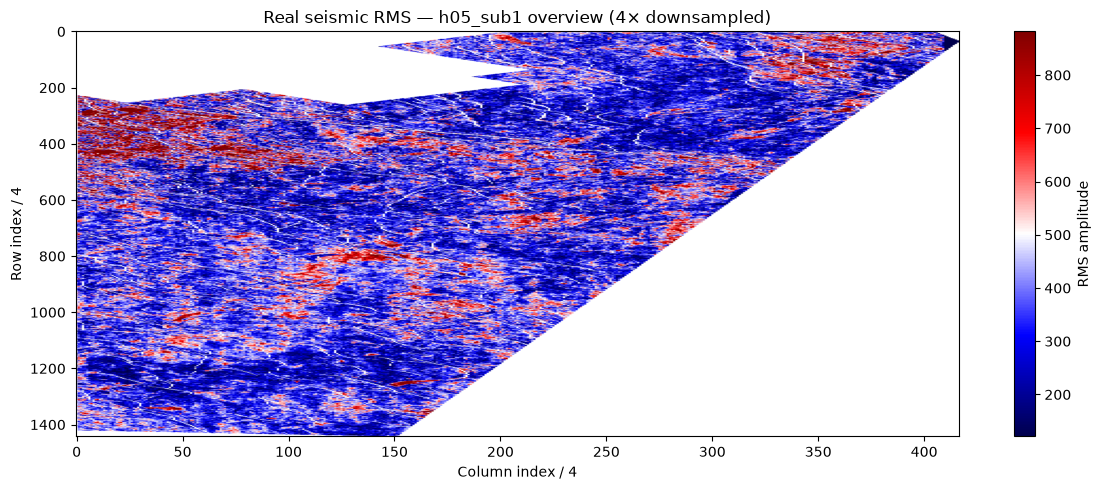

In [3]:
step = 4  # downsample for fast display
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    ref_grid[::step, ::step],
    cmap="seismic",
    vmin=np.nanpercentile(ref_grid, 2),
    vmax=np.nanpercentile(ref_grid, 98),
    aspect="auto",
)
plt.colorbar(im, ax=ax, label="RMS amplitude")
ax.set_title("Real seismic RMS — h05_sub1 overview (4× downsampled)")
ax.set_xlabel("Column index / 4")
ax.set_ylabel("Row index / 4")
plt.tight_layout()
plt.show()

## 2  Build reference CDF

Reference CDF built from 5,691,070 values
  unclipped range : 0.0 – 3737.2
  clipped @99.5%  : 0.0 – 1188.9


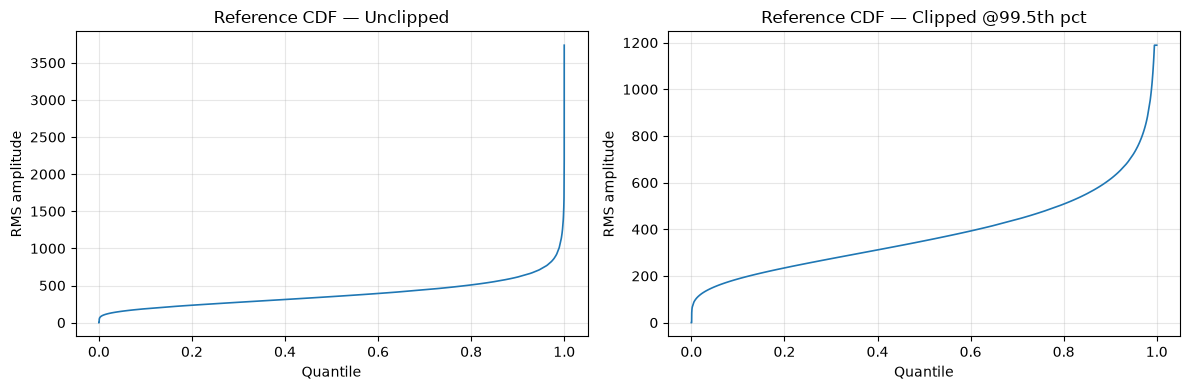

In [11]:
CLIP_PCT = 99.5  # upper percentile; removes acquisition noise spikes

# Reload module to pick up the updated build_reference_cdf
import importlib
import diffsim.data.style_match as _sm
importlib.reload(_sm)
from diffsim.data.style_match import build_reference_cdf, histogram_match_rms, sample_reference_patches

ref_sorted = build_reference_cdf(ref_grid, clip_percentile=CLIP_PCT)
ref_sorted_raw = build_reference_cdf(ref_grid, clip_percentile=100.0)

print(f"Reference CDF built from {len(ref_sorted):,} values")
print(f"  unclipped range : {ref_sorted_raw[0]:.1f} – {ref_sorted_raw[-1]:.1f}")
print(f"  clipped @{CLIP_PCT}%  : {ref_sorted[0]:.1f} – {ref_sorted[-1]:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, label in [
    (axes[0], ref_sorted_raw, "Unclipped"),
    (axes[1], ref_sorted,     f"Clipped @{CLIP_PCT}th pct"),
]:
    ax.plot(np.linspace(0, 1, len(vals)), vals, lw=1.2)
    ax.set_xlabel("Quantile")
    ax.set_ylabel("RMS amplitude")
    ax.set_title(f"Reference CDF — {label}")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3  Sample representative patches from the reference

Sampled 6 reference patches of size 64×64


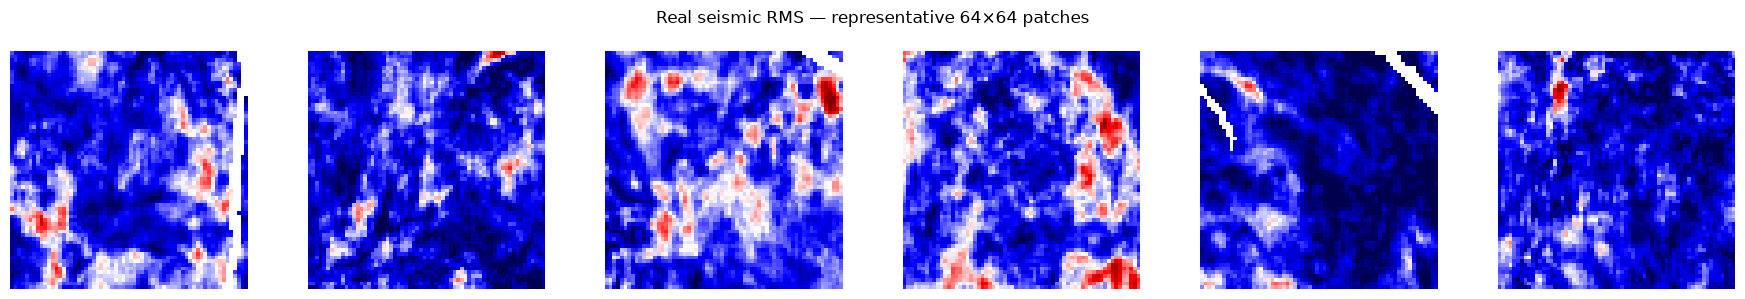

In [5]:
PATCH_SIZE = 64
rng = np.random.default_rng(42)

ref_patches = sample_reference_patches(ref_grid, PATCH_SIZE, n_patches=6, rng=rng)
print(f"Sampled {len(ref_patches)} reference patches of size {PATCH_SIZE}×{PATCH_SIZE}")

# Display reference patches
vmin_ref = np.nanpercentile(ref_grid, 2)
vmax_ref = np.nanpercentile(ref_grid, 98)

fig, axes = plt.subplots(1, len(ref_patches), figsize=(3 * len(ref_patches), 3))
for ax, patch in zip(axes, ref_patches):
    ax.imshow(patch, cmap="seismic", vmin=vmin_ref, vmax=vmax_ref)
    ax.axis("off")
fig.suptitle("Real seismic RMS — representative 64×64 patches")
plt.tight_layout()
plt.show()

## 4  Load a sample Flumy RMS and apply style matching

Edit `FLUMY_RMS_PATH` to point to any `.npy` RMS file from your Flumy cube output.

In [6]:
# --- Edit this path ---
FLUMY_RMS_DIR = Path("/mnt/sda_data/tharitt/diffsim/data/flumy3d/rms")

rms_files = sorted(FLUMY_RMS_DIR.glob("*.npy")) if FLUMY_RMS_DIR.is_dir() else []
print(f"Found {len(rms_files)} Flumy RMS cubes in {FLUMY_RMS_DIR}")
if rms_files:
    print("  First:", rms_files[0].name)

Found 675 Flumy RMS cubes in /mnt/sda_data/tharitt/diffsim/data/flumy3d/rms
  First: ng10_isbx100_seed10.npy


In [7]:
if not rms_files:
    # Synthesise a small dummy RMS to demonstrate the matching
    print("No Flumy RMS files found — using a synthetic dummy for demonstration.")
    rng_dummy = np.random.default_rng(7)
    # Simulate low-amplitude Flumy RMS (roughly Gaussian, different scale from seismic)
    dummy_cube = np.abs(rng_dummy.normal(loc=20.0, scale=8.0, size=(200, 200, 10))).astype(np.float32)
    rms_cube = dummy_cube
    rms_file_label = "synthetic dummy"
else:
    rms_cube = np.load(rms_files[0])
    rms_file_label = rms_files[0].name

print(f"Loaded: {rms_file_label}  shape={rms_cube.shape}  "
      f"range=[{rms_cube.min():.3f}, {rms_cube.max():.3f}]")

Loaded: ng10_isbx100_seed10.npy  shape=(256, 256, 29)  range=[0.042, 0.131]


In [12]:
# Extract a 64×64 horizontal slice from the Flumy cube
z_idx = rms_cube.shape[2] // 2  # middle depth
slice_2d = rms_cube[:, :, z_idx]

# Random 64×64 crop
h, w = slice_2d.shape
if h >= PATCH_SIZE and w >= PATCH_SIZE:
    r0 = rng.integers(0, h - PATCH_SIZE + 1)
    c0 = rng.integers(0, w - PATCH_SIZE + 1)
    flumy_patch_raw = slice_2d[r0 : r0 + PATCH_SIZE, c0 : c0 + PATCH_SIZE].copy()
else:
    flumy_patch_raw = slice_2d[:PATCH_SIZE, :PATCH_SIZE].copy()

# Apply histogram matching
flumy_patch_matched = histogram_match_rms(flumy_patch_raw, ref_sorted)

print(f"Raw Flumy patch  — mean: {flumy_patch_raw.mean():.2f}, std: {flumy_patch_raw.std():.2f}, "
      f"range: [{flumy_patch_raw.min():.2f}, {flumy_patch_raw.max():.2f}]")
print(f"Matched Flumy    — mean: {flumy_patch_matched.mean():.2f}, std: {flumy_patch_matched.std():.2f}, "
      f"range: [{flumy_patch_matched.min():.2f}, {flumy_patch_matched.max():.2f}]")
print(f"Real seismic ref — mean: {np.nanmean(ref_grid):.2f}, std: {np.nanstd(ref_grid):.2f}, "
      f"range: [{np.nanmin(ref_grid):.2f}, {np.nanmax(ref_grid):.2f}]")

Raw Flumy patch  — mean: 0.08, std: 0.01, range: [0.05, 0.13]
Matched Flumy    — mean: 383.05, std: 183.03, range: [0.00, 1188.94]
Real seismic ref — mean: 384.09, std: 188.79, range: [0.00, 3737.22]


## 5  Side-by-side comparison

/tmp/ipykernel_2201425/3446074547.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


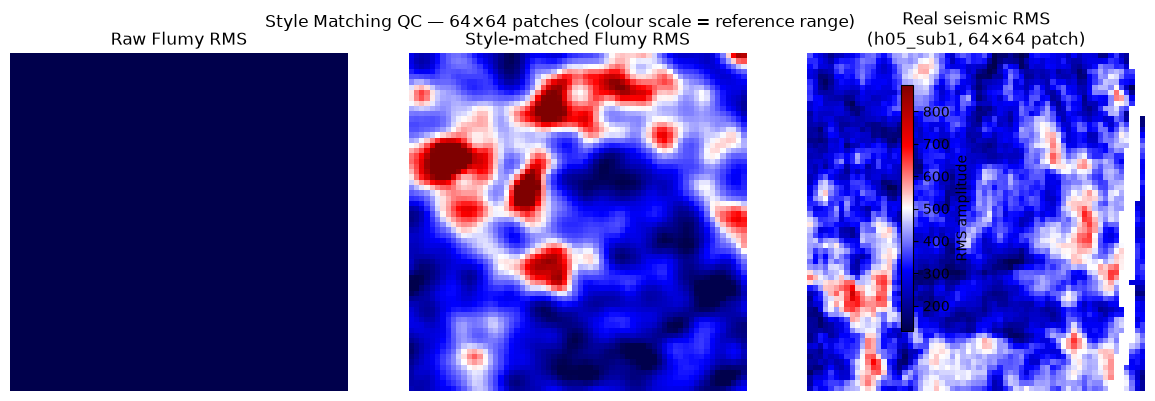

Saved: style_match_side_by_side.png


In [13]:
ref_example_patch = ref_patches[0]

# Use a shared colour scale anchored to the reference for fair comparison
vmin = np.nanpercentile(ref_grid, 2)
vmax = np.nanpercentile(ref_grid, 98)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(flumy_patch_raw, cmap="seismic", vmin=vmin, vmax=vmax)
axes[0].set_title("Raw Flumy RMS")
axes[0].axis("off")

im1 = axes[1].imshow(flumy_patch_matched, cmap="seismic", vmin=vmin, vmax=vmax)
axes[1].set_title("Style-matched Flumy RMS")
axes[1].axis("off")

im2 = axes[2].imshow(ref_example_patch, cmap="seismic", vmin=vmin, vmax=vmax)
axes[2].set_title("Real seismic RMS\n(h05_sub1, 64×64 patch)")
axes[2].axis("off")

fig.colorbar(im2, ax=axes, label="RMS amplitude", shrink=0.8)
fig.suptitle("Style Matching QC — 64×64 patches (colour scale = reference range)")
plt.tight_layout()
plt.savefig("style_match_side_by_side.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: style_match_side_by_side.png")

## 6  Amplitude distribution comparison

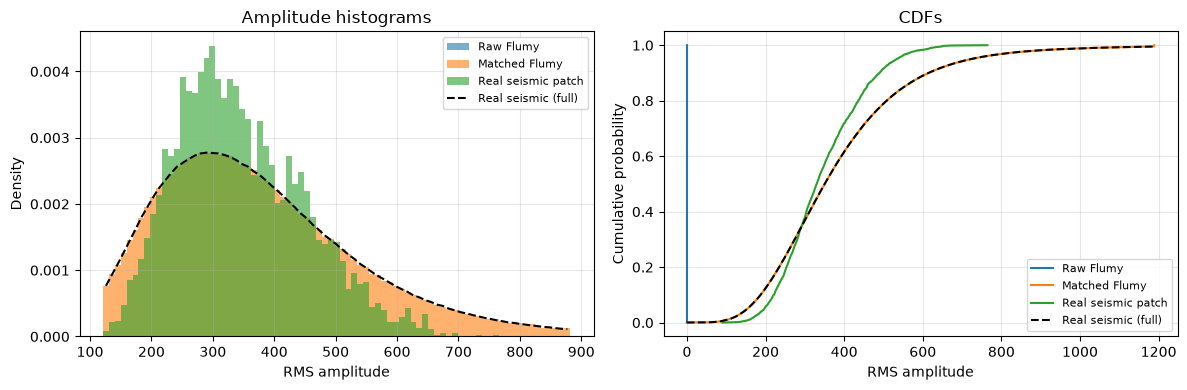

Saved: style_match_distributions.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
bins = np.linspace(vmin, vmax, 80)
axes[0].hist(flumy_patch_raw.ravel(), bins=bins, alpha=0.6, label="Raw Flumy", density=True)
axes[0].hist(flumy_patch_matched.ravel(), bins=bins, alpha=0.6, label="Matched Flumy", density=True)
axes[0].hist(ref_example_patch[np.isfinite(ref_example_patch)].ravel(),
             bins=bins, alpha=0.6, label="Real seismic patch", density=True)
# Reference full distribution (thin line)
counts, edges = np.histogram(ref_sorted, bins=bins, density=True)
centres = 0.5 * (edges[:-1] + edges[1:])
axes[0].plot(centres, counts, "k--", lw=1.5, label="Real seismic (full)")
axes[0].set_xlabel("RMS amplitude")
axes[0].set_ylabel("Density")
axes[0].set_title("Amplitude histograms")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# CDF
for arr, label, color in [
    (flumy_patch_raw.ravel(), "Raw Flumy", "tab:blue"),
    (flumy_patch_matched.ravel(), "Matched Flumy", "tab:orange"),
    (ref_example_patch[np.isfinite(ref_example_patch)].ravel(), "Real seismic patch", "tab:green"),
]:
    s = np.sort(arr)
    axes[1].plot(s, np.linspace(0, 1, len(s)), label=label, color=color)
axes[1].plot(ref_sorted, np.linspace(0, 1, len(ref_sorted)), "k--", lw=1.5, label="Real seismic (full)")
axes[1].set_xlabel("RMS amplitude")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("CDFs")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("style_match_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: style_match_distributions.png")

## 7  Spatial extent note

| | Cell spacing | 64-cell patch |
|---|---|---|
| h05_sub1 (real seismic) | ~25 m | ~1600 m |
| Flumy mesh | 20 m | 1280 m |

The ~20% scale difference means a Flumy patch represents a slightly smaller area than the same-pixel seismic patch.  
For distribution matching this is irrelevant; for spatial inference (patch-by-patch covering h05) the stride/overlap should be adjusted accordingly.